*import libraries*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


*Load the dataset*

In [4]:
!pip install -q datasets

In [5]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
dataset = load_dataset("pittawat/letter_recognition")

print(dataset)

c:\Users\ADMIN\Desktop\Handwriting_CNN_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ADMIN\Desktop\Handwriting_CNN_Project\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\datasets--pittawat--letter_recognition. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as a

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 26000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2600
    })
})


*check one imgage*

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 26


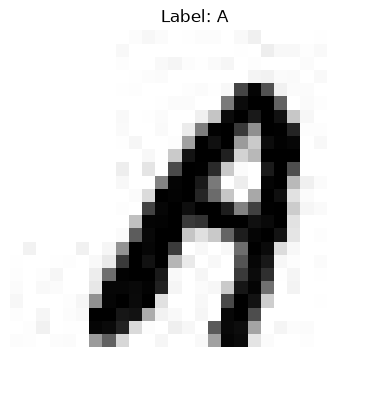

In [6]:
# Get A-Z class names
class_names = dataset["train"].features["label"].names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

# Show one image
sample = dataset["train"][0]

plt.imshow(sample["image"], cmap="gray")
plt.title(f"Label: {class_names[sample['label']]}")
plt.axis("off")
plt.show()

*prepare Train, Validation, and Test.*

In [7]:
from sklearn.model_selection import train_test_split

# Convert images and labels to NumPy arrays
def images_to_numpy(split):
    images = np.stack([np.array(img) for img in split["image"]])
    labels = np.array(split["label"])
    return images, labels

# Original training data
X_full, y_full = images_to_numpy(dataset["train"])

# Original test data
X_test, y_test = images_to_numpy(dataset["test"])

print("Full training data:", X_full.shape)
print("Test data:", X_test.shape)

Full training data: (26000, 28, 28, 3)
Test data: (2600, 28, 28, 3)


In [45]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (20800, 28, 28, 3)
Validation: (5200, 28, 28, 3)
Test: (2600, 28, 28, 1)


*Preprocessing*

In [9]:
# Convert RGB images to grayscale
X_train = np.mean(X_train, axis=-1)
X_val = np.mean(X_val, axis=-1)
X_test = np.mean(X_test, axis=-1)

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add ONE channel for grayscale
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (20800, 28, 28, 1)
Validation: (5200, 28, 28, 1)
Test: (2600, 28, 28, 1)


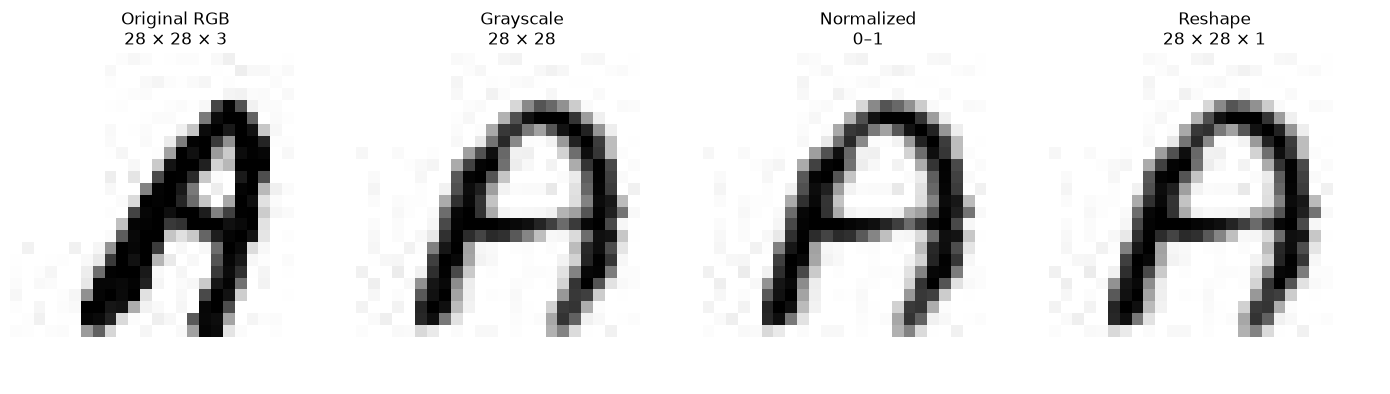

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# RGB image: choose one image
rgb_image = np.array(dataset["train"][0]["image"])

# Use a DIFFERENT image for the processed pipeline
gray_source = np.array(dataset["train"][1]["image"])

# Step 1: RGB → Grayscale
gray_image = np.mean(gray_source, axis=-1)

# Step 2: Grayscale → Normalize
normalized_image = gray_image.astype("float32") / 255.0

# Step 3: Normalize → Reshape
reshaped_image = normalized_image.reshape(28, 28, 1)

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# 1. RGB
axes[0].imshow(rgb_image)
axes[0].set_title("Original RGB\n28 × 28 × 3")

# 2. Grayscale
axes[1].imshow(gray_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Grayscale\n28 × 28")

# 3. Normalized
axes[2].imshow(normalized_image, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Normalized\n0–1")

# 4. Reshape
axes[3].imshow(reshaped_image[:, :, 0], cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Reshape\n28 × 28 × 1")

# Remove axes
for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    "preprocessing_4_steps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import os
from PIL import Image

splits = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "test": (X_test, y_test)
}

for split_name, (images, labels) in splits.items():

    for class_id, class_name in enumerate(class_names):

        folder = os.path.join("data", split_name, class_name)
        os.makedirs(folder, exist_ok=True)

        indices = np.where(labels == class_id)[0]

        for count, i in enumerate(indices):

            # Convert normalized image back to 0-255
            img = (images[i].squeeze() * 255).astype("uint8")

            image_path = os.path.join(
                folder,
                f"{class_name}_{count}.png"
            )

            Image.fromarray(img).save(image_path)

print("All images saved successfully!")

All images saved successfully!


In [10]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

print("Data augmentation created successfully.")

Data augmentation created successfully.


*build the model*

In [12]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Data augmentation
    data_augmentation,

    # CNN Layer 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 3
    layers.Conv2D(128, (3, 3), activation="relu"),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(26, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,610 (951.60 KB)

 Trainable params: 243,610 (951.60 KB)

 Non-trainable params: 0 (0.00 B)

#Compile the model

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


*Train the model*

In [14]:
history_no_stop = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=64
)

Epoch 1/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3426 - loss: 2.1957 - val_accuracy: 0.8885 - val_loss: 0.3993
Epoch 2/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7225 - loss: 0.8960 - val_accuracy: 0.9258 - val_loss: 0.2586
Epoch 3/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8064 - loss: 0.6310 - val_accuracy: 0.9533 - val_loss: 0.1726
Epoch 4/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8468 - loss: 0.5132 - val_accuracy: 0.9473 - val_loss: 0.1866
Epoch 5/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8652 - loss: 0.4520 - val_accuracy: 0.9573 - val_loss: 0.1527
Epoch 6/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8759 - loss: 0.4092 - val_accuracy: 0.9583 - val_loss: 0.1551
Epoch 7/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8872 - loss: 0.3806 - val_accuracy: 0.9608 - val_loss: 0.1530
Epoch 8/35
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8938 - loss: 0.3551 - val_accuracy: 0.

In [32]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test accuracy: {test_accuracy * 100:.2f}%")

Test accuracy: 97.73%


In [33]:
import os

os.makedirs("models", exist_ok=True)

model_path = "models/final_handwriting_cnn_97_73percent.keras"

model.save(model_path)

print("Final model saved successfully!")
print("Location:", model_path)

Final model saved successfully!
Location: models/final_handwriting_cnn_97_73percent.keras


In [34]:
import json

with open("training_history.json", "w") as f:
    json.dump(history_no_stop.history, f)

print("Training history saved successfully!")

Training history saved successfully!


*Training & Validation Accuracy Plot*

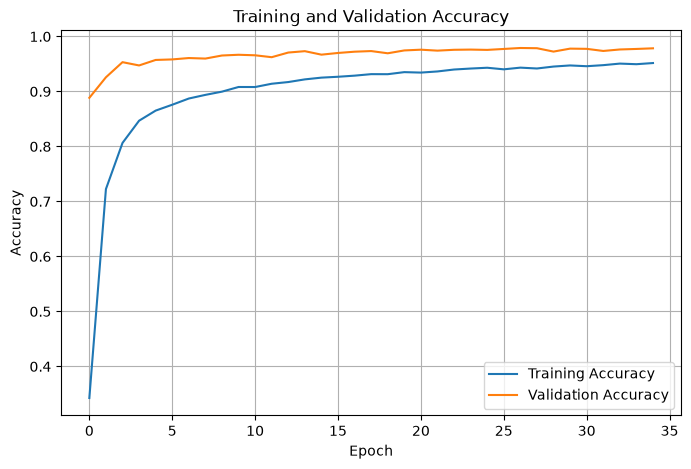

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history_no_stop.history["accuracy"], label="Training Accuracy")
plt.plot(history_no_stop.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

*Training & Validation Loss Plot*

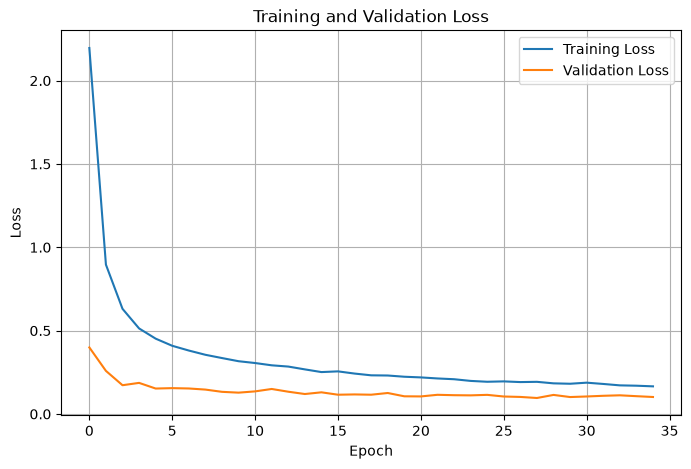

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(history_no_stop.history["loss"], label="Training Loss")
plt.plot(history_no_stop.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


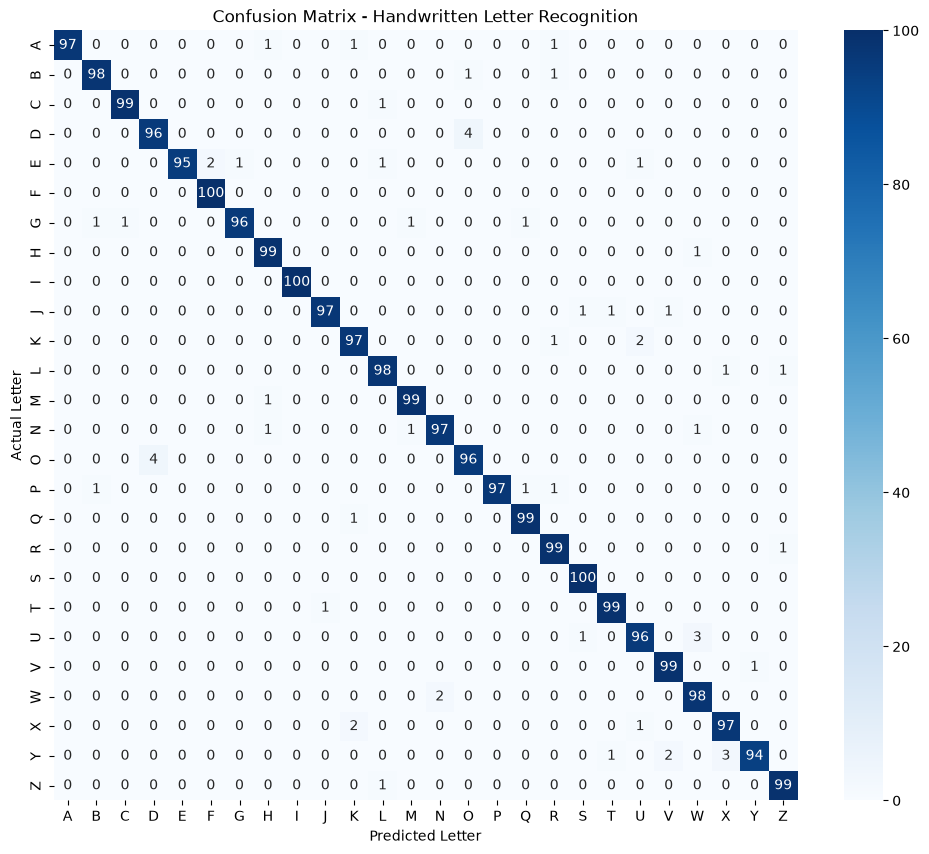

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Predict all test images
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Letter")
plt.ylabel("Actual Letter")
plt.title("Confusion Matrix - Handwritten Letter Recognition")

plt.show()

*Classification Report*

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

           A       1.00      0.97      0.98       100
           B       0.98      0.98      0.98       100
           C       0.99      0.99      0.99       100
           D       0.96      0.96      0.96       100
           E       1.00      0.95      0.97       100
           F       0.98      1.00      0.99       100
           G       0.99      0.96      0.97       100
           H       0.97      0.99      0.98       100
           I       1.00      1.00      1.00       100
           J       0.99      0.97      0.98       100
           K       0.96      0.97      0.97       100
           L       0.97      0.98      0.98       100
           M       0.98      0.99      0.99       100
           N       0.98      0.97      0.97       100
           O       0.95      0.96      0.96       100
           P       1.00      0.97      0.98       100
           Q       0.98      0.99      0.99       100
           R       0.96    

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Find wrong predictions
wrong_indices = np.where(y_test != y_pred)[0]

print("Total wrong predictions:", len(wrong_indices))
print("Total test images:", len(y_test))

Total wrong predictions: 59
Total test images: 2600


*Show some wrong predictions*

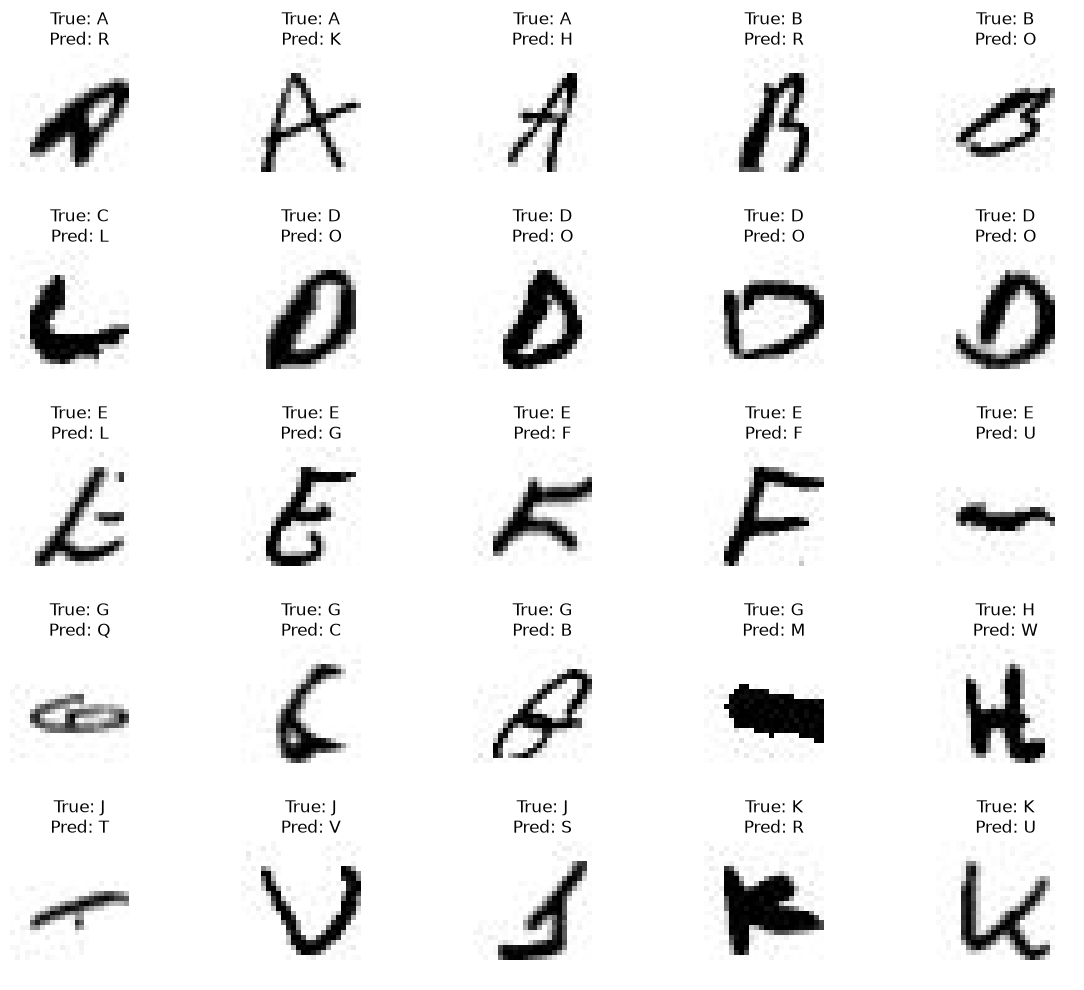

In [40]:

plt.figure(figsize=(12, 10))

for i, idx in enumerate(wrong_indices[:25]):
    plt.subplot(5, 5, i + 1)

    plt.imshow(X_test[idx].squeeze(), cmap="gray")

    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

*Test a real test image*

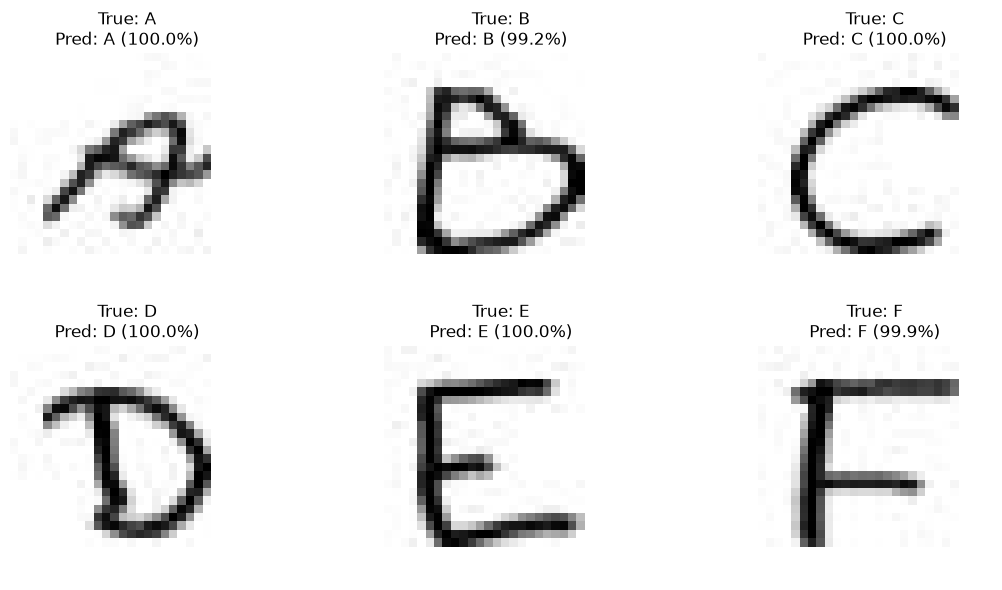

In [41]:
indices = [0, 100, 200, 300, 400, 500]

plt.figure(figsize=(12, 6))

for i, index in enumerate(indices):
    image = X_test[index]

    prediction = model.predict(
        image[np.newaxis, ...],
        verbose=0
    )

    predicted_id = np.argmax(prediction[0])
    predicted_label = class_names[predicted_id]
    true_label = class_names[y_test[index]]
    confidence = prediction[0][predicted_id]

    plt.subplot(2, 3, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label} ({confidence:.1%})"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

*final Demo prediction*

In [1]:
from tensorflow import keras

model = keras.models.load_model(
    "models/final_handwriting_cnn_97_73percent.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
class_names = [
    'A','B','C','D','E','F','G','H','I','J','K','L','M',
    'N','O','P','Q','R','S','T','U','V','W','X','Y','Z'
]

In [4]:
import gradio as gr
import numpy as np
from PIL import Image


def predict_letter(img):
    if img is None:
        return "Please draw a letter."

    # Gradio ImageEditor returns a dictionary
    if isinstance(img, dict):
        img = img["composite"]

    # Convert to grayscale
    img = Image.fromarray(img).convert("L")

    img_array = np.array(img)

    # Make the background white and the letter dark
    if img_array.mean() < 127:
        img_array = 255 - img_array

    # Resize to the same size as training images
    img = Image.fromarray(img_array).resize((28, 28))

    # Normalize
    img_array = np.array(img).astype("float32") / 255.0

    # Add channel + batch dimensions
    img_array = img_array[..., np.newaxis]
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)

    predicted_id = np.argmax(prediction[0])
    predicted_letter = class_names[predicted_id]
    confidence = prediction[0][predicted_id]

    return f"{predicted_letter} | Confidence: {confidence:.2%}"


demo = gr.Interface(
    fn=predict_letter,
    inputs=gr.ImageEditor(
        type="numpy",
        image_mode="L",
        height=280,
        width=280,
        label="Draw a capital letter"
    ),
    outputs=gr.Textbox(label="Prediction"),
    title="A–Z Handwriting Recognition",
    description="Draw one English capital letter (A–Z)."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
